In [13]:
from datetime import timezone, datetime

#time_str = valid_time.astimezone(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

now_utc = datetime.now(timezone.utc)

def build_filename(storage, figtype, validtime, variant=None, order=None):

    time_str = validtime.astimezone(timezone.utc).strftime("%Y%m%d_%H%M%S")

    if variant is not None:
        filename = f"{storage}{figtype}_{time_str}_{variant}.png"
    else: 
        filename = f"{storage}{figtype}_{time_str}.png"

    return filename


build_filename("storage/", "asos_timeseries", now_utc)

'storage/asos_timeseries_20260904_162111.png'

In [2]:
# INPUTS ######################################################################

central_lat=34.5
# Latitude of the map's center (in degrees)
central_lon=-100
# Longitude of the map's center (in degrees)
extent=4
         
Satellite='vis' 

                     
import time
time0=time.time()
from datetime import datetime,timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from xarray import open_dataset
from xarray.backends import NetCDF4DataStore
from siphon.catalog import TDSCatalog
from scipy.interpolate import RectBivariateSpline
from matplotlib.colors import LinearSegmentedColormap

# PHYSICAL CONSTANTS ##########################################################

g=9.81 # Acceleration due to gravity (m s^-1)
Rd=287.04 # Dry air gas constant (J kg^-1 K^-1)
Rv=461.5 # Water vapor gas constant (J kg^-1 K^-1)
cpd=1005 # Specific heat of dry air at constant pressure (J kg^-1 K^-1)
cpv=1870 # Specific heat of water vapor at constant pressure (J kg^-1 K^-1)
cl=4190 # Specific heat of liquid water (J kg^-1 K^-1)
LvRef=2501000 # Enthalpy of vaporization of water at triple point temperature (J kg^-1 K^-1)
pref=611.2 # Equilibrium vapor pressure of water at triple point temperature (Pa)
Tref=273.15 # Triple point temperature (K)
Pr=1/3 # Turbulent Prandtl number
k=0.42 # Von-Karman constant
Lmix=120 # Mixing length (m)
alpha=0.8
sigma=1.1

# INPUT CALCULATIONS ############################################################

north=central_lat+extent
south=central_lat-extent
east=central_lon+extent
west=central_lon-extent

hodo_lon=np.arange(west+0.1*extent,east,0.2*extent)
hodo_lat=np.arange(south+0.1*extent,north,0.2*extent)

# Determine whether to use visible or IR imagery based on user input

# Visible
if Satellite=='vis':
    channel='Channel02'
    wavelength='0.64'
    sat_type='Visible Red'
    lowerclip=0
    upperclip=1
    gamma=2
    cmap_sat='gray'
    print('\nVisible Imagery Chosen\n(GOES-East ABI Channel 2, 0.64 μm Wavelength)')

# FUNCTIONS ###################################################################

def calc_latlon(data):
    # The math for this function was taken from 
    # https://makersportal.com/blog/2018/11/25/goes-r-satellite-latitude-and-
    # longitude-grid-projection-algorithm    
    x_1d = np.array(data['x'])*10**-6
    y_1d = np.array(data['y'])*10**-6
    x,y = np.meshgrid(x_1d,y_1d)
    r_eq=6378137.0
    r_pol=6356752.31414
    l_0=-75.00000000000001*(np.pi/180)
    h_sat=35786023.0
    H=r_eq+h_sat
    a=np.sin(x)**2+(np.cos(x)**2*(np.cos(y)**2+(r_eq/r_pol)**2*np.sin(y)**2))
    b=-2*H*np.cos(x)*np.cos(y)
    c=H**2-r_eq**2
    r_s=(-b-(b**2-4*a*c)**0.5)/(2*a)
    print('^\nThis is expected behavior; the code is working as intended')
    s_x=r_s*np.cos(x)*np.cos(y)
    s_y=-r_s*np.sin(x)
    s_z=r_s*np.cos(x)*np.sin(y)
    lat=np.arctan((r_eq/r_pol)**2*(s_z/np.sqrt((H-s_x)**2+s_y**2)))*(180/np.pi)
    lon=(l_0-np.arctan(s_y/(H-s_x)))*(180/np.pi)
    return lon,lat,x_1d*h_sat,y_1d*h_sat


    
def grid_interp(lon,lat,grid):
    return RectBivariateSpline(lon,lat,grid.T)(hodo_lon,hodo_lat)

# DATA RETRIEVAL ##############################################################

# Download GOES data
sat_url='https://thredds.ucar.edu/thredds/catalog/satellite/goes/east/products/CloudAndMoistureImagery/CONUS/'+channel+'/current/catalog.xml'
sat_cat=TDSCatalog(sat_url)
sat_ds = sat_cat.datasets[-1]
sat_url=sat_ds.access_urls['OPENDAP']
sat_data=open_dataset(sat_url, engine='netcdf4')
sat_valid_datetime=datetime(int(sat_url[-17:-13]),1,1,int(sat_url[-10:-8]),int(sat_url[-8:-6]))+timedelta(int(sat_url[-13:-10])-1)
sat_valid=str(sat_valid_datetime)   



# PLOTTING ####################################################################

# Gamma correction
sat=np.array(sat_data['Sectorized_CMI'])**(1/gamma)
sat=np.clip(sat,lowerclip,upperclip)

# Mask values not in the specified domain
# Speeds up plotting for later, especially with the higher-resolution visible
# imagery
sat_lon,sat_lat,x_sat,y_sat=calc_latlon(sat_data)
sat_bool=np.logical_and(np.logical_and(sat_lat>=south-extent/2,sat_lat<=north+extent/2),np.logical_and(sat_lon>=west-extent/2,sat_lon<=east+extent/2))
sat=np.ma.masked_where(sat_bool==False,sat)

# Create a tuple representing the bounds of the satellite data to be plotted
imextent_sat=(x_sat.min(),x_sat.max(),y_sat.min(),y_sat.max())

# Create a geostationary axis
globe_sat=ccrs.Globe(semimajor_axis=sat_data['fixedgrid_projection'].semi_major_axis,semiminor_axis=sat_data['fixedgrid_projection'].semi_minor_axis)
crs_sat=ccrs.Geostationary(central_longitude=sat_data['fixedgrid_projection'].longitude_of_projection_origin,globe=globe_sat)

# Create figure
# If you are running this through a terminal, you may need to add some code to
# save the figure to a specified directory
fig=plt.figure(dpi=500)

# Create cartopy axis
ax=plt.axes(projection=ccrs.PlateCarree())

# Make axis invisible
ax.axis('off')

# Set axis bounds
ax.set_extent([west,east,south,north])

# Add geographic features
#ax.coastlines(linewidth=0.75,edgecolor='deepskyblue',zorder=1)
ax.add_feature(cfeature.STATES.with_scale('50m'),edgecolor='deepskyblue',linewidth=0.75,zorder=1)

# Display satellite imagery
im_sat=ax.imshow(sat,origin='upper',extent=imextent_sat,interpolation=None,transform=crs_sat,cmap=cmap_sat,vmin=lowerclip,vmax=upperclip,zorder=0)

fig.set_facecolor("black")
ax.set_facecolor("black")

plt.show()


Visible Imagery Chosen
(GOES-East ABI Channel 2, 0.64 μm Wavelength)


KeyboardInterrupt: 

In [1]:
from datetime import datetime, timedelta
from metpy.calc import reduce_point_density
from awips.dataaccess import DataAccessLayer
from dynamicserialize.dstypes.com.raytheon.uf.common.time import TimeRange
import numpy as np
import metpy.calc as mpcalc
from metpy.units import units
import pandas as pd
import cartopy.crs as ccrs

def get_metar_pressure_last_3hrs(date=datetime.utcnow()):
    """
    Retrieve METAR sea-level pressure observations for the last 3 hours.
    """
    from datetime import datetime, timedelta
    from awips.dataaccess import DataAccessLayer
    from dynamicserialize.dstypes.com.raytheon.uf.common.time import TimeRange
    import pandas as pd
    import numpy as np

    # Connect to EDEX
    DataAccessLayer.changeEDEXHost("edex-cloud.unidata.ucar.edu")
    request = DataAccessLayer.newDataRequest("obs")

    params = ["stationName", "latitude", "longitude", "seaLevelPress"]
    request.setParameters(*params)

    # Time window: last 3 hours
    end_time = date
    start_time = date - timedelta(hours=3)
    timerange = TimeRange(start_time, end_time)

    response = DataAccessLayer.getGeometryData(request, timerange)

    rows = []
    for ob in response:

        avail = ob.getParameters()
        if "seaLevelPress" not in avail:
            continue

        stid = ob.getString("stationName")
        lat = ob.getNumber("latitude")
        lon = ob.getNumber("longitude")
        pres = ob.getNumber("seaLevelPress")  # Pa
        pres_hpa = pres / 100.0

        ### ------------ FIXED TIMESTAMP LOGIC -------------
        # refTime = Java Date object → use getTime()
        ms = ob.getDataTime().getRefTime().getTime()  # milliseconds since epoch
        t = datetime.utcfromtimestamp(ms / 1000.0)
        ### -------------------------------------------------

        rows.append({
            "stid": stid,
            "latitude": lat,
            "longitude": lon,
            "time": t,
            "sea_level_pressure": pres_hpa
        })

    df = pd.DataFrame(rows).sort_values(["stid", "time"]).reset_index(drop=True)
    return df


def trim_metar_data(df, lat_min=None, lat_max=None,
                    lon_min=None, lon_max=None):
    """
    Trim METAR observations to a geographic bounding box.

    Parameters
    ----------
    df : pandas.DataFrame
        METAR observations. Must include 'latitude' and 'longitude'
    lat_min, lat_max : float
        Minimum and maximum latitude
    lon_min, lon_max : float
        Minimum and maximum longitude

    Returns
    -------
    trimmed_df : pandas.DataFrame
        Only observations inside bounding box
    """

    trimmed_df = df.copy()

    if lat_min is not None:
        trimmed_df = trimmed_df[trimmed_df['latitude'] >= lat_min]
    if lat_max is not None:
        trimmed_df = trimmed_df[trimmed_df['latitude'] <= lat_max]
    if lon_min is not None:
        trimmed_df = trimmed_df[trimmed_df['longitude'] >= lon_min]
    if lon_max is not None:
        trimmed_df = trimmed_df[trimmed_df['longitude'] <= lon_max]

    trimmed_df = trimmed_df.reset_index(drop=True)
    return trimmed_df


def compute_pressure_tendency(df, pressure_column="sea_level_pressure",
                              missing_value=-99.99):
    """
    Computes 3-hour pressure tendency for METAR stations.
    Keeps lat/lon information.
    """

    df = df.copy()

    # Clean missing values
    df[pressure_column] = df[pressure_column].replace(missing_value, np.nan)
    df = df.dropna(subset=[pressure_column])

    results = []

    for stid, sdf in df.groupby("stid"):
        sdf = sdf.sort_values("time")

        if sdf.empty:
            continue

        # Most recent valid pressure
        latest = sdf.iloc[-1]
        latest_time = latest["time"]
        latest_p = latest[pressure_column]
        lat = latest["latitude"]
        lon = latest["longitude"]

        # 3-hr-before target
        target_time = latest_time - pd.Timedelta(hours=3)

        sdf["dt"] = (sdf["time"] - target_time).abs()
        close = sdf.loc[sdf["dt"] <= pd.Timedelta(hours=1)]  # ±1 hr window

        if close.empty:
            continue

        past = close.sort_values("dt").iloc[0]
        past_p = past[pressure_column]

        tendency = latest_p - past_p

        results.append({
            "stid": stid,
            "latitude": lat,
            "longitude": lon,
            "p_recent": latest_p,
            "p_3hr": past_p,
            "tendency": tendency
        })

    return pd.DataFrame(results)


C:\Users\kjgil\AppData\Local\Temp\ipykernel_23164\248112375.py:11: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  def get_metar_pressure_last_3hrs(date=datetime.utcnow()):


In [2]:
center_lat = 46.841203
center_lon = -98.777673
box_size   = 7
west = center_lon  - box_size
east = center_lon  + box_size
south = center_lat - box_size
north = center_lat + box_size

data = get_metar_pressure_last_3hrs()
trimmed_data = trim_metar_data(data, lat_min=south-2, lat_max=north+2,
                                     lon_min=west -10, lon_max=east+10)
hr3_data = compute_pressure_tendency(trimmed_data)

C:\Users\kjgil\AppData\Local\Temp\ipykernel_23164\248112375.py:51: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  t = datetime.utcfromtimestamp(ms / 1000.0)


In [3]:
from scipy.interpolate import Rbf
import numpy as np

def grid_pressure_tendency(tdf, 
                           grid_spacing_deg=0.25,
                           function='linear',
                           smooth=0.0):
    """
    Grids station pressure tendencies using RBF interpolation.

    Parameters
    ----------
    tdf : DataFrame
        Output of compute_pressure_tendency() must include:
        ['latitude','longitude','tendency']
    grid_spacing_deg : float
        Grid resolution in degrees (0.25° ~ 25 km)
    function : str
        RBF kernel ('linear', 'thin_plate', 'cubic', 'gaussian', etc.)
    smooth : float
        Smoothing factor. 0 = exact fit.

    Returns
    -------
    grid_lats, grid_lons, grid_values
    """

    # 1. Input
    lats = tdf["latitude"].to_numpy()
    lons = tdf["longitude"].to_numpy()
    vals = tdf["tendency"].to_numpy()

    # 2. Build output grid
    lat_min, lat_max = lats.min() - 1, lats.max() + 1
    lon_min, lon_max = lons.min() - 1, lons.max() + 1

    grid_lats = np.arange(lat_min, lat_max, grid_spacing_deg)
    grid_lons = np.arange(lon_min, lon_max, grid_spacing_deg)

    LON, LAT = np.meshgrid(grid_lons, grid_lats)

    # 3. RBF interpolation
    rbf = Rbf(lons, lats, vals, function=function, smooth=smooth)
    GRID = rbf(LON, LAT)

    return LAT, LON, GRID

LAT, LON, GRID = grid_pressure_tendency(hr3_data)

In [4]:
import numpy as np
import scipy.ndimage as ndimage

def compute_gradient(LAT, LON, GRID):
    """
    Compute the gradient of gridded pressure tendency.
    
    Parameters
    ----------
    LAT, LON : 2D arrays
        Latitude and longitude grid (from meshgrid)
    GRID : 2D array
        Gridded pressure tendency values (hPa)

    Returns
    -------
    dP_dy, dP_dx : 2D arrays
        Northward (Pa/km) and eastward (Pa/km) gradients
    """

    # Convert degrees to meters
    # Approximate: 1 deg lat ~ 111.32 km, 1 deg lon ~ 111.32 km * cos(lat)
    lat_radians = np.deg2rad(LAT)
    dx = np.gradient(LON, axis=1) * 111320 * np.cos(lat_radians)  # meters
    dy = np.gradient(LAT, axis=0) * 111320                           # meters

    # Compute gradient along y (lat) and x (lon)
    dP_dy = np.gradient(mpcalc.smooth_n_point(GRID,9, 50), axis=0) / dy   # hPa per meter north
    dP_dx = np.gradient(mpcalc.smooth_n_point(GRID,9, 50), axis=1) / dx   # hPa per meter east

    # Optional: convert to hPa per km
    dP_dy *= 1000
    dP_dx *= 1000

    return dP_dy, dP_dx

dP_dy, dP_dx = compute_gradient(LAT, LON, GRID)
magnitude = np.hypot(dP_dx, dP_dy)

In [5]:
import warnings
warnings.filterwarnings("ignore")

# IMPORTS
import time as comp_time
import sys
import warnings

from siphon.catalog import TDSCatalog
from siphon.ncss import NCSS
from datetime import datetime

from xarray.backends import NetCDF4DataStore
import xarray as xr



### RAP ANALYSIS ###
#########################################################################################################
def analysis(center_lat=37.86, center_lon=-98.61, box_size=20):
    st = comp_time.time()

    print(f'    ACCESSING RAP DATA')

    # define dataset URL & try to access it to make sure it works
    url = 'http://thredds.ucar.edu/thredds/catalog/grib/NCEP/RAP/CONUS_13km/latest.xml'
    #url = 'https://thredds.ucar.edu/thredds/ncss/grid/grib/NCEP/RAP/CONUS_13km/RR_CONUS_13km_20250315_1800.grib2'
    try:
        cat = TDSCatalog(url)
        source = 'RAP ANALYSIS'
    except:
        sys.exit(
            "NCSS URL FAILED -- THIS HAPPENS WHEN A BAD REQUEST IS MADE. RAP Analysis data may not be available at this time.")
        pass

    # set up TDS query
    latest_ds = list(cat.datasets.values())[0]
    ncss = NCSS(latest_ds.access_urls['NetcdfSubset'])
    query = ncss.query()
    # Find start time
    start_time = ncss.metadata.time_span['begin']
    fcst_date = datetime.strptime(start_time, '%Y-%m-%dT%H:%M:%SZ')
    year1 = fcst_date.strftime('%Y')
    month1 = fcst_date.strftime('%m')
    day1 = fcst_date.strftime('%d')
    hour1 = fcst_date.strftime('%H')
    # Subset data by time
    query.time(fcst_date).accept('netcdf4')
    # Subsets data by variables
    query.variables('MSLP_MAPS_System_Reduction_msl',
                    'Pressure_surface',
                    'Geopotential_height_isobaric',
                    'Temperature_isobaric',
                    'Relative_humidity_isobaric',
                    'Temperature_height_above_ground',
                    'Relative_humidity_height_above_ground',
                    'u-component_of_wind_height_above_ground', 'v-component_of_wind_height_above_ground',
                    'u-component_of_wind_isobaric', 'v-component_of_wind_isobaric',
                    'Convective_available_potential_energy_surface',
                    'Storm_relative_helicity_height_above_ground_layer',
                    'U-Component_Storm_Motion_height_above_ground_layer',
                    'V-Component_Storm_Motion_height_above_ground_layer').add_lonlat()

    # Subset data by lat-lon domain
    query.lonlat_box(north=center_lat+box_size, west=center_lon-box_size, east=center_lon+box_size, south=center_lat-box_size)

    # Gets data
    ncss_data = ncss.get_data(query)

    raw_data = xr.open_dataset(NetCDF4DataStore(ncss_data)).metpy.parse_cf()


    elapsed_time = comp_time.time() - st
    print('    RAP DATA LOADED.....Time elapsed:', comp_time.strftime("%H:%M:%S", comp_time.gmtime(elapsed_time)))

    return raw_data


#########################################################################################################


# pull rap data
raw_data = analysis(center_lat, center_lon, box_size=15)

# LATS & LONS
lats = raw_data.variables['lat'][:]
lons = raw_data.variables['lon'][:]

# PRES LEVS
pres_levs = raw_data['isobaric'][:]
pres_levs = pres_levs / 100

# DATE INFO
try:
    data_date = raw_data['time'].values[0]
except:
    data_date = raw_data['time1'].values[0]
    pass
valid_date = f'{data_date}'

pres_sfc = ndimage.gaussian_filter(raw_data.variables['MSLP_MAPS_System_Reduction_msl'][0], sigma=0.75)

    ACCESSING RAP DATA
    RAP DATA LOADED.....Time elapsed: 00:00:11


In [6]:
valid_date

'2025-12-18T14:00:00.000000000'

In [7]:
rho=1.225
dpdx_Pa_per_m = (dP_dx * 100) / 10800.0  # hPa/km -> Pa/m/s
dpdy_Pa_per_m = (dP_dy * 100) / 10800.0

# Coriolis parameter f
omega = 7.2921e-5  # rad/s
phi = np.deg2rad(LAT)
f = 2 * omega * np.sin(phi)

# Avoid divide by zero near equator
f = np.where(np.abs(f) < 1e-5, 1e-5, f)

# Isallobaric wind components (surface approximation)
u_iso = - dpdy_Pa_per_m / (rho * f)  # eastward
v_iso = dpdx_Pa_per_m / (rho * f)  

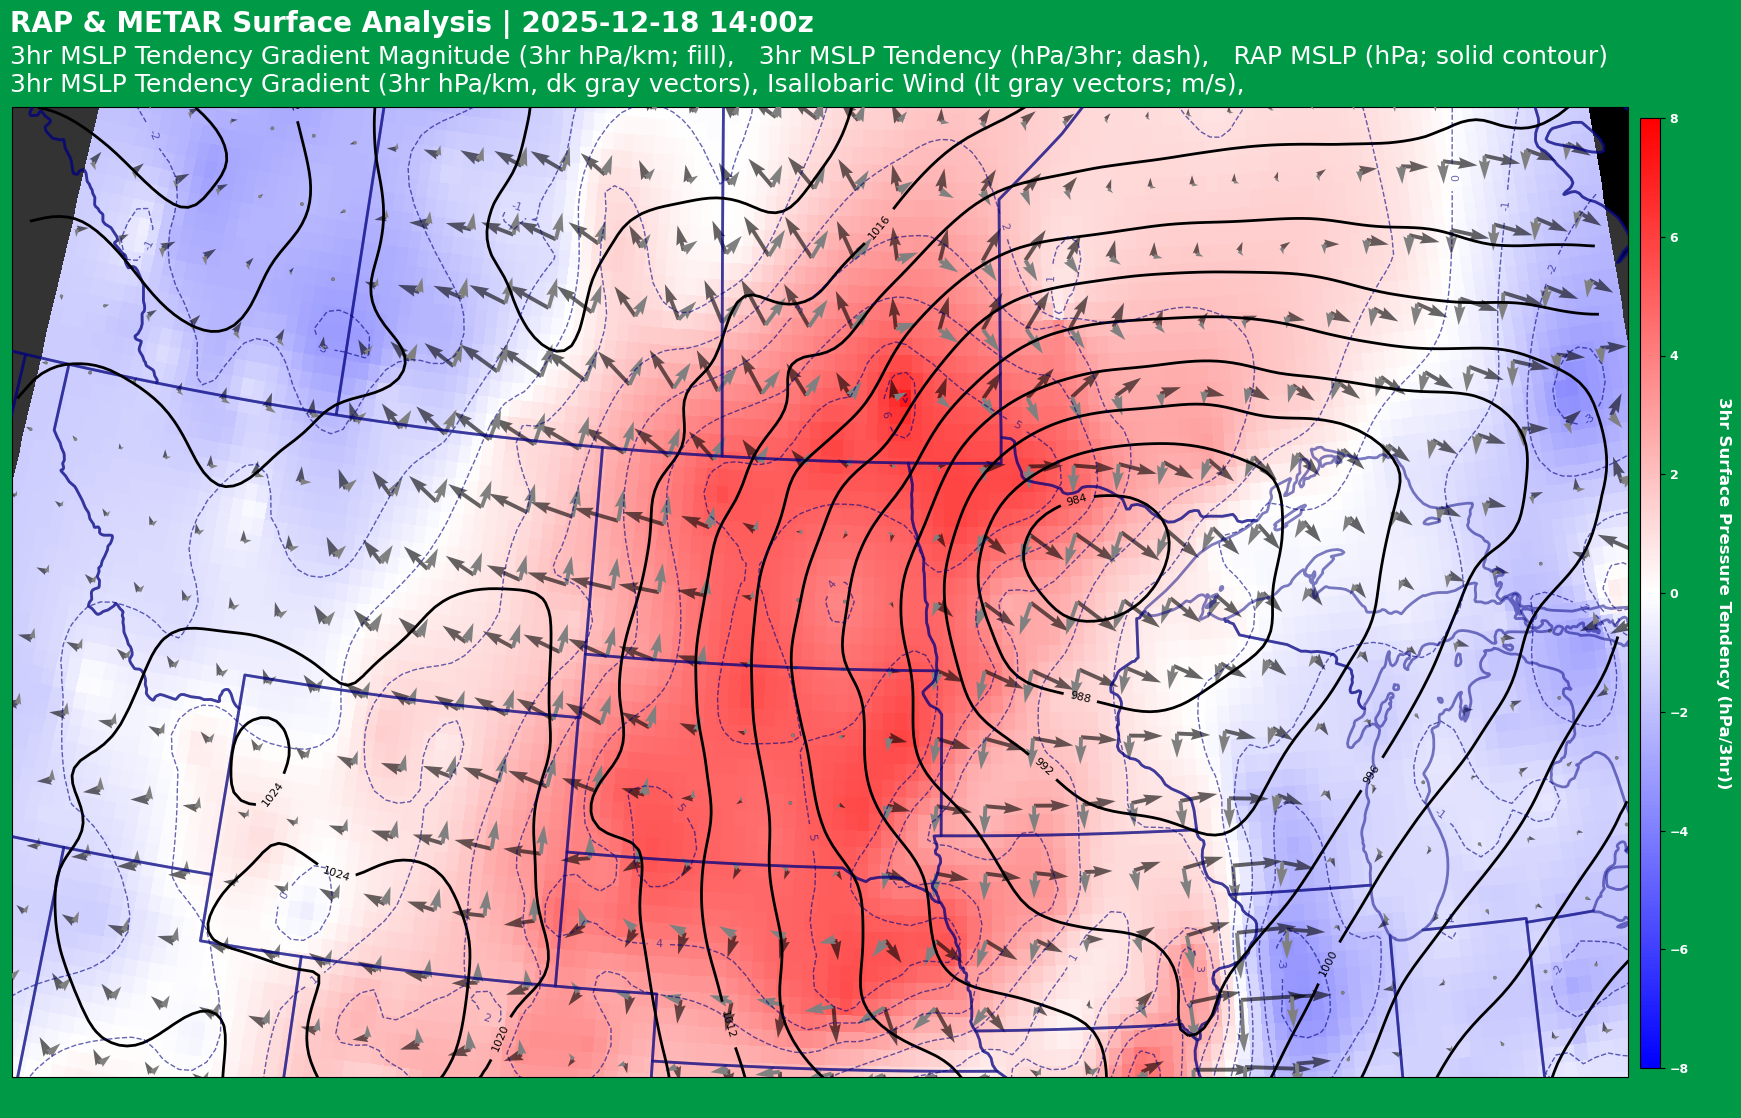

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# build mpa function
def build_map(extent=[west, east, south, north], projection=ccrs.LambertConformal(), style='light'):
    fig = plt.figure(figsize=(20, 10))
    fig.set_facecolor('#009946')
    ax = plt.axes(projection=projection)

    ax.set_extent(extent)
    ax.set_box_aspect(0.6)

    if style == 'light':
        color = 'gray'
        alpha = 0.5
    else:
        color = 'black'
        alpha = 0.8

    ax.add_feature(cfeature.STATES, edgecolor='navy', alpha=0.5, linestyle='-', linewidth=2, zorder=10)
    ax.add_feature(cfeature.LAND, facecolor=color, alpha=alpha, zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor=color, alpha=alpha + 0.2, zorder=0)
    ax.add_feature(cfeature.COASTLINE, color='navy', alpha=0.5, linestyle='-', linewidth=2, zorder=11)

    plt.tight_layout()

    return fig, ax

fig, ax = build_map(style='dark')

# Plot gridded tendency
pm = ax.pcolormesh(LON, LAT, GRID, shading='auto', zorder=1.3, cmap='bwr', vmax=8, vmin=-8, transform=ccrs.PlateCarree())

###################################################################
# RAP MSLP
###################################################################
cs = ax.contour(lons, lats, pres_sfc/100, np.arange(904, 1054, 4), colors='black',
                linewidths=2.0, linestyles='-',
                transform=ccrs.PlateCarree(), zorder=11)
plt.clabel(cs, fontsize=8, inline=1, inline_spacing=10, fmt='%i',
           rightside_up=True, use_clabeltext=True)

skip = (slice(None, None, 4), slice(None, None, 4))  # skip arrows to reduce clutter
Q = ax.quiver(
    LON[skip], LAT[skip], -dP_dx[skip], -dP_dy[skip],
    scale=0.4, color='black', pivot='tail', transform=ccrs.PlateCarree(), zorder=3,  alpha=0.6
)

Q = ax.quiver(
    LON[skip], LAT[skip], u_iso[skip], v_iso[skip],
    scale=40, color='gray', pivot='tail', transform=ccrs.PlateCarree(), zorder=4,
)

cs = ax.contour(LON, LAT, GRID, np.arange(-8, 8, 1), colors='navy',
                linewidths=1.0, linestyles='--',
                transform=ccrs.PlateCarree(), zorder=11, alpha=0.6)
plt.clabel(cs, fontsize=8, inline=1, inline_spacing=10, fmt='%i',
           rightside_up=True, use_clabeltext=True)

#################################
# ADD MAP EXTRAS
#################################
# plot title, add one to the left with model name and data names, add another to the right with time info
plt.figtext(0.095, 1.06, f'RAP & METAR Surface Analysis | {valid_date[0:10]} {valid_date[11:-13]}z', weight='bold', ha='left', fontsize=20, color='white')
plt.figtext(0.095, 1.00, f'3hr MSLP Tendency Gradient Magnitude (3hr hPa/km; fill),   3hr MSLP Tendency (hPa/3hr; dash),   RAP MSLP (hPa; solid contour)\n3hr MSLP Tendency Gradient (3hr hPa/km, dk gray vectors), Isallobaric Wind (lt gray vectors; m/s),', ha='left', fontsize=18, color='white')
plt.figtext(0.915, 1.04, f' ', ha='left', fontsize=20)
plt.figtext(0.915, -0.01, f' ', ha='left', fontsize=20)
#colorbar for filled contour
cax = fig.add_axes([0.91, 0.024, 0.01, 0.95])
cbar = fig.colorbar(pm, cax=cax, orientation='vertical', extendrect=True)
cax.text(3.8, 0.5, "3hr Surface Pressure Tendency (hPa/3hr))", ha='left',va='center',rotation=270, color='white',fontsize=12,fontweight='bold',transform=cax.transAxes)
cbar.ax.tick_params(axis='y', labelcolor='white') 
for t in cbar.ax.get_yticklabels():
    t.set_fontweight('bold')
    t.set_fontsize(9)
cbar.ax.set_facecolor('black')